In [2]:
import pandas as pd

# load dataset again
data = pd.read_csv('delhi_heat_dataset.csv')

# remove missing values
data = data.dropna()

print(data.head())

              X          Y     VALUE
1884  77.101727  29.154059 -0.199967
1885  77.101997  29.154059 -0.186338
1886  77.102266  29.154059 -0.195168
1887  77.102536  29.154059 -0.213253
1888  77.102805  29.154059 -0.213253


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# features
X = data[['X','Y']]

# target
y = data['VALUE']

# split data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train,y_train)

print("Model trained successfully")

Model trained successfully


In [4]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.8743066850682437
RMSE: 0.014921956157525559


In [5]:
print(data.columns)

Index(['X', 'Y', 'VALUE'], dtype='object')


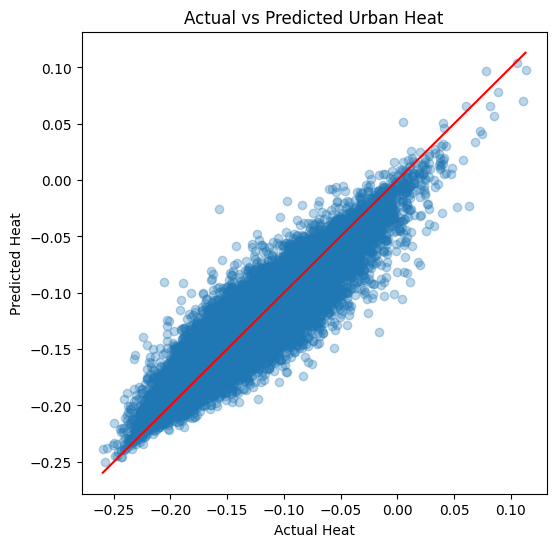

In [6]:
import matplotlib.pyplot as plt

pred = model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.3)
plt.xlabel("Actual Heat")
plt.ylabel("Predicted Heat")
plt.title("Actual vs Predicted Urban Heat")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

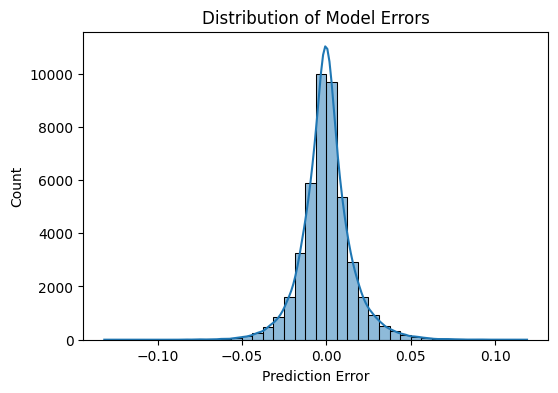

In [7]:
import seaborn as sns

errors = y_test - pred

plt.figure(figsize=(6,4))
sns.histplot(errors, bins=40, kde=True)

plt.xlabel("Prediction Error")
plt.title("Distribution of Model Errors")
plt.show()

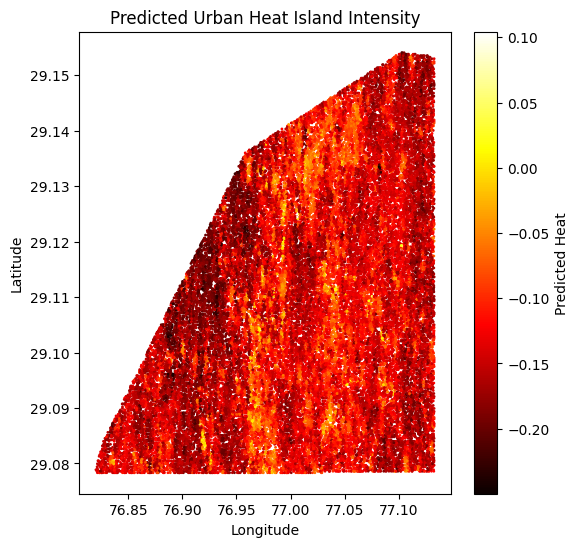

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(X_test['X'], X_test['Y'],
            c=pred,
            cmap='hot',
            s=1)

plt.colorbar(label="Predicted Heat")
plt.title("Predicted Urban Heat Island Intensity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [9]:
sample = data.sample(10000)
sample.to_csv("delhi_heat_dataset_sample.csv", index=False)


In [10]:
from google.colab import files
files.download("delhi_heat_dataset_sample.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>